# Tsunami
This notebook is used to visualize the output of the tsunami.f90 program. The aim of the program is to calculate the shift of a ocean wave by the wind. The problem is represented in a mathematical form
$$\frac{\partial h}{\partial t} + c \cdot \nabla h = 0$$
The velocity is assumed to be constant and the height is assumed to be a scalar field. The program output was written in a output file. Each row of the output file contains the height of the wave, as a function of the distance from the origin, at a time steps. The wave data is plotted at four time steps to visualize the advection of the wave from left to right. In the last plot the wave returns at the origin according to the chosen boundary constraint that simulates what happens to a wave traveling on a spherical or cylindrical surface.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [3]:
input_file = 'tsunami_output.txt'

In [12]:
data = [line.rstrip().split() for line in open(input_file).readlines()]
len(data)

100

In [21]:
time = [float(line[0]) for line in data]

We copy the heights for each time step into a NumPy array

In [23]:
h = np.array([[float(x) for x in line[1:]] for line in data])
h.shape

(100, 100)

We plot the height data for only four time steps

In [24]:
x = np.arange(1, h.shape[1] + 1)
time_steps = [0, 25, 50, 75]

Text(0.5, 0, 'Spatial grid index')

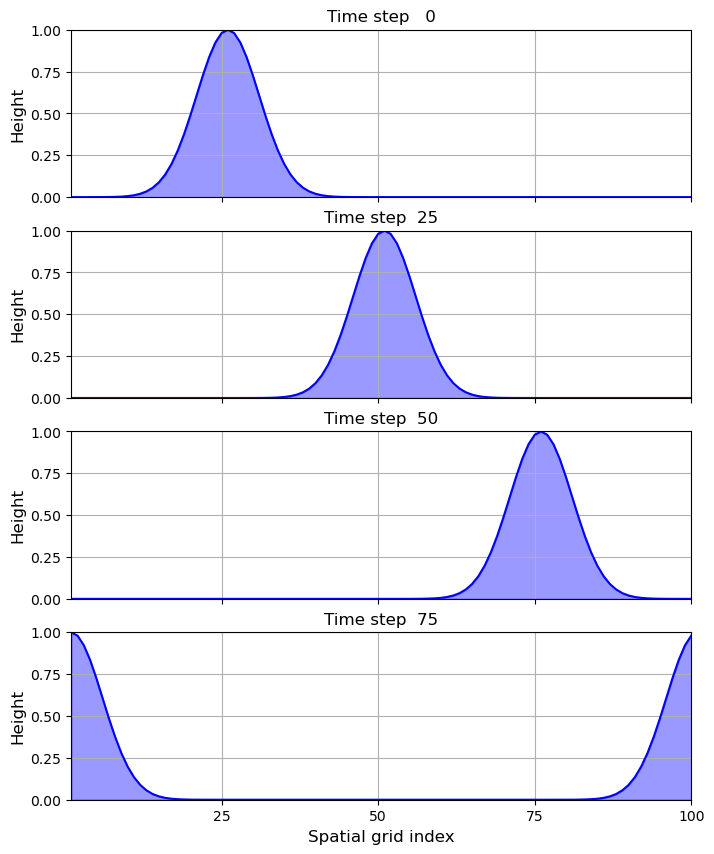

In [26]:
fig = plt.figure(figsize=(8, 10))
axes = [plt.subplot2grid((4, 1), (row, 0), colspan=1, rowspan=1) for row in range(4)]

for ax in axes:
    n = axes.index(ax)
    ax.plot(x, h[time_steps[n], :], 'b-')
    ax.fill_between(x, 0, h[time_steps[n], :], color='b', alpha=0.4)
    ax.grid()
    ax.set_xlim(1, 100)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Height', fontsize=12)
    ax.set_xticks([25, 50, 75, 100])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

for ax in axes:
    n = axes.index(ax)
    ax.set_title('Time step ' + '%3i' % time_steps[n])

for ax in axes[:-1]:
    ax.set_xticklabels([])

axes[-1].set_xlabel('', fontsize=12) 
axes[-1].set_xlabel('Spatial grid index') 